In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/drive/MyDrive/fraudTrain.csv.zip")
df.head()

,Index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,1/1/2019 0:00,2.703190e+15,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",3/9/1988,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,1/1/2019 0:01,3.534090e+15,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1/12/1967,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,1/1/2019 0:03,3.755340e+14,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,3/28/1986,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df.shape

(1048575, 23)

In [ ]:
df = df[df['amt'] > 50].reset_index(drop=True)
df

,Index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,1,1/1/2019 0:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2,1/1/2019 0:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
2,5,1/1/2019 0:04,4.767270e+15,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,40.3750,-75.2045,2158,Transport planner,6/19/1961,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0
3,7,1/1/2019 0:05,6.011360e+15,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,38.8432,-78.6003,6018,"Designer, multimedia",8/21/1947,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0
4,9,1/1/2019 0:06,2.720830e+15,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,36.5220,-87.3490,151785,Pathologist,3/28/1974,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504363,1048554,3/10/2020 16:03,4.469780e+18,fraud_Bode-Rempel,kids_pets,72.56,Gregory,Graham,M,4005 Dana Glens,...,42.7280,-71.1810,47249,Market researcher,11/22/1980,819b1427624ba12e9a7850ff1ba7cdb7,1362931381,43.682207,-71.997351,0
504364,1048557,3/10/2020 16:03,3.798970e+14,"fraud_Walter, Hettinger and Kessler",personal_care,73.38,Frank,Key,M,5537 Jessica Plaza,...,38.3039,-85.4834,3263,Stage manager,2/28/1930,b8d1dc622a253072dbbdeefa527f93e0,1362931430,38.061912,-84.791897,0
504365,1048563,3/10/2020 16:04,2.712210e+15,"fraud_Weimann, Kuhic and Beahan",shopping_pos,184.88,Jenna,Brooks,F,50872 Alex Plain Suite 088,...,30.4066,-91.1468,378909,"Designer, furniture",2/22/1977,a7890f15bfef7389fbe8af3b2c078d60,1362931490,29.430735,-91.281149,0
504366,1048570,3/10/2020 16:07,6.011980e+15,fraud_Fadel Inc,health_fitness,77.00,Haley,Wagner,F,05561 Farrell Crescent,...,39.0305,-76.5515,92106,"Accountant, chartered certified",5/28/1943,45ecd198c65e81e597db22e8d2ef7361,1362931649,38.779464,-76.317042,0


In [ ]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['hour'] = df['trans_date_trans_time'].dt.hour
df

,Index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour
0,1,2019-01-01 00:00:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,6/21/1978,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0
1,2,2019-01-01 00:00:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1/19/1962,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0
2,5,2019-01-01 00:04:00,4.767270e+15,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,-75.2045,2158,Transport planner,6/19/1961,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,0
3,7,2019-01-01 00:05:00,6.011360e+15,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,-78.6003,6018,"Designer, multimedia",8/21/1947,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,0
4,9,2019-01-01 00:06:00,2.720830e+15,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,-87.3490,151785,Pathologist,3/28/1974,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504363,1048554,2020-03-10 16:03:00,4.469780e+18,fraud_Bode-Rempel,kids_pets,72.56,Gregory,Graham,M,4005 Dana Glens,...,-71.1810,47249,Market researcher,11/22/1980,819b1427624ba12e9a7850ff1ba7cdb7,1362931381,43.682207,-71.997351,0,16
504364,1048557,2020-03-10 16:03:00,3.798970e+14,"fraud_Walter, Hettinger and Kessler",personal_care,73.38,Frank,Key,M,5537 Jessica Plaza,...,-85.4834,3263,Stage manager,2/28/1930,b8d1dc622a253072dbbdeefa527f93e0,1362931430,38.061912,-84.791897,0,16
504365,1048563,2020-03-10 16:04:00,2.712210e+15,"fraud_Weimann, Kuhic and Beahan",shopping_pos,184.88,Jenna,Brooks,F,50872 Alex Plain Suite 088,...,-91.1468,378909,"Designer, furniture",2/22/1977,a7890f15bfef7389fbe8af3b2c078d60,1362931490,29.430735,-91.281149,0,16
504366,1048570,2020-03-10 16:07:00,6.011980e+15,fraud_Fadel Inc,health_fitness,77.00,Haley,Wagner,F,05561 Farrell Crescent,...,-76.5515,92106,"Accountant, chartered certified",5/28/1943,45ecd198c65e81e597db22e8d2ef7361,1362931649,38.779464,-76.317042,0,16


In [ ]:
df['dob'] = pd.to_datetime(df['dob'])
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365
df

,Index,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,age
0,1,2019-01-01 00:00:00,6.304230e+11,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,40
1,2,2019-01-01 00:00:00,3.885950e+13,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,56
2,5,2019-01-01 00:04:00,4.767270e+15,"fraud_Stroman, Hudson and Erdman",gas_transport,94.63,Jennifer,Conner,F,4655 David Island,...,2158,Transport planner,1961-06-19,189a841a0a8ba03058526bcfe566aab5,1325376248,40.653382,-76.152667,0,0,57
3,7,2019-01-01 00:05:00,6.011360e+15,fraud_Corwin-Collins,gas_transport,71.65,Steven,Williams,M,231 Flores Pass Suite 720,...,6018,"Designer, multimedia",1947-08-21,6d294ed2cc447d2c71c7171a3d54967c,1325376308,38.948089,-78.540296,0,0,71
4,9,2019-01-01 00:06:00,2.720830e+15,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,198.39,Melissa,Aguilar,F,21326 Taylor Squares Suite 708,...,151785,Pathologist,1974-03-28,3b9014ea8fb80bd65de0b1463b00b00e,1325376361,37.179198,-87.485381,0,0,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504363,1048554,2020-03-10 16:03:00,4.469780e+18,fraud_Bode-Rempel,kids_pets,72.56,Gregory,Graham,M,4005 Dana Glens,...,47249,Market researcher,1980-11-22,819b1427624ba12e9a7850ff1ba7cdb7,1362931381,43.682207,-71.997351,0,16,39
504364,1048557,2020-03-10 16:03:00,3.798970e+14,"fraud_Walter, Hettinger and Kessler",personal_care,73.38,Frank,Key,M,5537 Jessica Plaza,...,3263,Stage manager,1930-02-28,b8d1dc622a253072dbbdeefa527f93e0,1362931430,38.061912,-84.791897,0,16,90
504365,1048563,2020-03-10 16:04:00,2.712210e+15,"fraud_Weimann, Kuhic and Beahan",shopping_pos,184.88,Jenna,Brooks,F,50872 Alex Plain Suite 088,...,378909,"Designer, furniture",1977-02-22,a7890f15bfef7389fbe8af3b2c078d60,1362931490,29.430735,-91.281149,0,16,43
504366,1048570,2020-03-10 16:07:00,6.011980e+15,fraud_Fadel Inc,health_fitness,77.00,Haley,Wagner,F,05561 Farrell Crescent,...,92106,"Accountant, chartered certified",1943-05-28,45ecd198c65e81e597db22e8d2ef7361,1362931649,38.779464,-76.317042,0,16,76


In [ ]:
df.drop(columns=[
    'cc_num', 'first', 'last', 'street', 'city',
    'state', 'zip', 'trans_num', 'merchant',
    'dob', 'trans_date_trans_time'
], inplace=True)
df

,Index,category,amt,gender,lat,long,city_pop,job,unix_time,merch_lat,merch_long,is_fraud,hour,age
0,1,grocery_pos,107.23,F,48.8878,-118.2105,149,Special educational needs teacher,1325376044,49.159047,-118.186462,0,0,40
1,2,entertainment,220.11,M,42.1808,-112.2620,4154,Nature conservation officer,1325376051,43.150704,-112.154481,0,0,56
2,5,gas_transport,94.63,F,40.3750,-75.2045,2158,Transport planner,1325376248,40.653382,-76.152667,0,0,57
3,7,gas_transport,71.65,M,38.8432,-78.6003,6018,"Designer, multimedia",1325376308,38.948089,-78.540296,0,0,71
4,9,grocery_pos,198.39,F,36.5220,-87.3490,151785,Pathologist,1325376361,37.179198,-87.485381,0,0,44
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504363,1048554,kids_pets,72.56,M,42.7280,-71.1810,47249,Market researcher,1362931381,43.682207,-71.997351,0,16,39
504364,1048557,personal_care,73.38,M,38.3039,-85.4834,3263,Stage manager,1362931430,38.061912,-84.791897,0,16,90
504365,1048563,shopping_pos,184.88,F,30.4066,-91.1468,378909,"Designer, furniture",1362931490,29.430735,-91.281149,0,16,43
504366,1048570,health_fitness,77.00,F,39.0305,-76.5515,92106,"Accountant, chartered certified",1362931649,38.779464,-76.317042,0,16,76


In [ ]:
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [ ]:
cat_cols = df.select_dtypes(include='object').columns
df[cat_cols] = df[cat_cols].fillna('Unknown')


In [ ]:
for col in ['category', 'gender', 'job']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])


In [ ]:
TARGET = 'is_fraud'
X = df.drop(TARGET, axis=1)
y = df[TARGET]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [ ]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[[95779  4153]
 [   60   882]]
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     99932
           1       0.18      0.94      0.30       942

    accuracy                           0.96    100874
   macro avg       0.59      0.95      0.64    100874
weighted avg       0.99      0.96      0.97    100874

ROC-AUC: 0.9780131168600168


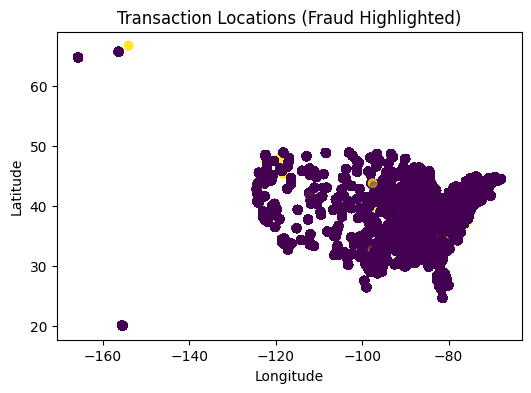

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df['long'], df['lat'], c=df['is_fraud'], alpha=0.3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Transaction Locations (Fraud Highlighted)")
plt.show()